# RF-DETR Segmentation - Rice Raw COCO trên Kaggle

Phase 3+4 được train bằng raw dataset trên Kaggle, không dùng `processed/` làm nguồn chính.

- Domain: `rice` / lúa
- Raw annotation: `rice_leaf_disease/annotations.coco.json`


Raw Kaggle data dự kiến:

```text
/kaggle/input/datasets/tongthanhphuc/cafe-rice/
|-- coffee_leaf_disease/
|   |-- 0/
|   |-- 1/
|   |-- 2/
|   |-- 3/
|   `-- annotations.coco.json
`-- rice_leaf_disease/
    |-- BrownSpot/
    |-- Healthy/
    |-- Hispa/
    |-- LeafBlast/
    `-- annotations.coco.json
```

Notebook sẽ đọc COCO raw, remap class cho domain `rice`, chia train/valid/test theo tỷ lệ 70/15/15, rồi tạo dataset RF-DETR tại `/kaggle/working/rfdetr_datasets/rice`.


In [1]:
# Kaggle: bật Internet trong Notebook Settings trước khi chạy.
!python --version
!nvidia-smi
!pip install -q --upgrade pip
!pip install -q "rfdetr[train,loggers,metrics]" supervision pycocotools huggingface_hub opencv-python-headless pandas matplotlib seaborn tqdm pillow tabulate || pip install -q rfdetr supervision pycocotools huggingface_hub opencv-python-headless pandas matplotlib seaborn tqdm pillow tabulate

Python 3.12.13
Wed Jun  3 16:59:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------------

In [2]:
import inspect
import json
import os
import random
import shutil
import time
import warnings
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from pycocotools import mask as mask_utils
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IS_KAGGLE = Path("/kaggle").exists()
WORK_DIR = Path("/kaggle/working" if IS_KAGGLE else ".").resolve()
INPUT_DIR = Path("/kaggle/input" if IS_KAGGLE else ".").resolve()
ARTIFACT_DIR = WORK_DIR / "rf_detr_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
RUN_TRAINING = os.getenv("RUN_TRAINING", "1") == "1"
RUN_EVALUATION = os.getenv("RUN_EVALUATION", "1") == "1"
RUN_HF_PUSH = 0
EXPORT_ONNX = os.getenv("EXPORT_ONNX", "0") == "1"

print(f"Work dir: {WORK_DIR}")
print(f"Input dir: {INPUT_DIR}")
print(f"Device: {DEVICE}")
print(f"Quick run: {QUICK_RUN}")

Work dir: /kaggle/working
Input dir: /kaggle/input
Device: cuda
Quick run: False


In [3]:
# Thư mục raw data quan sát được trong mining-data.ipynb:
# /kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease
#
# Nếu Kaggle mount dataset ở đường dẫn khác, hãy đặt RAW_DATA_DIR trỏ tới thư mục
# chứa coffee_leaf_disease/ và/hoặc rice_leaf_disease/.

NOTEBOOK_DOMAIN = "rice"
SELECTED_DOMAINS = [NOTEBOOK_DOMAIN]

DOMAIN_DIRS = {
    "coffee": "coffee_leaf_disease",
    "rice": "rice_leaf_disease",
}

DEFAULT_RAW_DIRS = [
    Path("/kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease"),
    Path("/kaggle/input/datasets/tongthanhphuc/cafe-rice"),
    Path("/kaggle/input/rice-coffee-leaf-disease"),
    Path("/kaggle/input/cafe-rice"),
    Path("/kaggle/input/cafe_rice"),
    Path("/kaggle/input/coffee-rice"),
    Path(".").resolve(),
]

# Tùy chọn: metadata processed không phải nguồn train chính, nhưng có thể giúp suy luận mapping nhãn.
DEFAULT_PROCESSED_DIRS = [
    Path("/kaggle/input/datasets/tongthanhphuc/cafe-rice/processed"),
    Path("/kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease/processed"),
    Path("/kaggle/input/cafe-rice/processed"),
    Path("/kaggle/input/cafe_rice/processed"),
    Path("processed").resolve(),
]

RAW_DATA_DIR = os.getenv("RAW_DATA_DIR", "").strip()
PROCESSED_DIR = os.getenv("PROCESSED_DIR", "").strip()
USE_PROCESSED_EXTRA = 0

if not RAW_DATA_DIR:
    required_folder = DOMAIN_DIRS[NOTEBOOK_DOMAIN]
    for candidate in DEFAULT_RAW_DIRS:
        if (candidate / required_folder / "annotations.coco.json").exists():
            RAW_DATA_DIR = str(candidate)
            break

if not PROCESSED_DIR:
    for candidate in DEFAULT_PROCESSED_DIRS:
        if (candidate / "metadata").exists():
            PROCESSED_DIR = str(candidate)
            break

HF_REPO_ID = (os.getenv("HF_REPO_ID", "") or "fuxi611/coffee-rice-leaf-disease-rf-detr").strip()
HF_UPLOAD_SINGLE_REPO = os.getenv("HF_UPLOAD_SINGLE_REPO", "1") == "1"
DEFAULT_MODEL_SIZE = os.getenv("RFDETR_MODEL_SIZE", "nano").lower()

TRAIN_CONFIG = {
    "name": "train_lr1e4",
    "model_size": DEFAULT_MODEL_SIZE,
    "epochs": 2 if QUICK_RUN else 8,
    "batch_size": 1 if QUICK_RUN else 2,
    "grad_accum_steps": 8 if QUICK_RUN else 4,
    "lr": 1e-4,
    "lr_encoder": 1.5e-4,
    "gradient_checkpointing": True,
    "early_stopping": True,
    "early_stopping_patience": 2 if QUICK_RUN else 5,
}

print(f"RAW_DATA_DIR = {RAW_DATA_DIR or '<not found>'}")
print(f"PROCESSED_DIR = {PROCESSED_DIR or '<not found>'}")
print(f"USE_PROCESSED_EXTRA = {USE_PROCESSED_EXTRA}")
print(f"NOTEBOOK_DOMAIN = {NOTEBOOK_DOMAIN}")
print(f"HF_REPO_ID = {HF_REPO_ID}")
print(f"HF_UPLOAD_SINGLE_REPO = {HF_UPLOAD_SINGLE_REPO}")
pd.DataFrame([TRAIN_CONFIG])

RAW_DATA_DIR = /kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease
PROCESSED_DIR = <not found>
USE_PROCESSED_EXTRA = 0
NOTEBOOK_DOMAIN = rice
HF_REPO_ID = fuxi611/coffee-rice-leaf-disease-rf-detr
HF_UPLOAD_SINGLE_REPO = True


,name,model_size,epochs,batch_size,grad_accum_steps,lr,lr_encoder,gradient_checkpointing,early_stopping,early_stopping_patience
0,train_lr1e4,nano,8,2,4,0.0001,0.00015,True,True,5


In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLIT_RATIOS = {"train": 0.70, "valid": 0.15, "test": 0.15}
RFDETR_DATASET_ROOT = WORK_DIR / "rfdetr_datasets"

# Kết quả ghi nhận từ mining-data.ipynb:
# coffee: 3879 ảnh, 3842 annotation, 5 category. Category id/name 0/"uit" là nhãn không hợp lệ/metadata không bệnh.
# rice: 3421 ảnh, 3720 annotation, 4 category. Một số ảnh có nhiều annotation.
INVALID_LABELS = {"", "none", "nan", "uit", "invalid", "background", "__background__"}

# Mapping dự phòng từ folder/category id raw của coffee sang nhãn sạch của project.
COFFEE_FOLDER_LABELS = {
    "0": "LeafMiner",
    "1": "PowderyMildew",
    "2": "Rust",
    "3": "AlgalLeafSpot",
}

DOMAIN_LABEL_ORDER = {
    "coffee": ["LeafMiner", "PowderyMildew", "Rust", "AlgalLeafSpot"],
    "rice": ["BrownSpot", "Healthy", "Hispa", "LeafBlast"],
}


def required_domain_folder(domain: str) -> str:
    return DOMAIN_DIRS[domain]


def is_valid_raw_root(root: Path, domain: str) -> bool:
    return (root / required_domain_folder(domain) / "annotations.coco.json").exists()


def find_raw_root() -> Path:
    if RAW_DATA_DIR:
        root = Path(RAW_DATA_DIR)
        if is_valid_raw_root(root, NOTEBOOK_DOMAIN):
            return root
        raise FileNotFoundError(
            f"RAW_DATA_DIR is invalid for domain={NOTEBOOK_DOMAIN}: {root}. "
            f"It must contain {required_domain_folder(NOTEBOOK_DOMAIN)}/annotations.coco.json."
        )

    candidates = list(DEFAULT_RAW_DIRS)
    if INPUT_DIR.exists():
        candidates.extend(INPUT_DIR.glob("*"))
        candidates.extend(INPUT_DIR.glob("*/*"))
        candidates.extend(INPUT_DIR.glob("*/*/*"))
        candidates.extend(INPUT_DIR.glob("*/*/*/*"))

    for root in candidates:
        if is_valid_raw_root(root, NOTEBOOK_DOMAIN):
            return root
    raise FileNotFoundError(
        f"Could not find raw dataset for domain={NOTEBOOK_DOMAIN}. "
        f"Set RAW_DATA_DIR to the folder containing {required_domain_folder(NOTEBOOK_DOMAIN)}/."
    )


def find_processed_root() -> Path | None:
    if PROCESSED_DIR:
        root = Path(PROCESSED_DIR)
        return root if (root / "metadata").exists() else None
    return None


def infer_coffee_mapping_from_processed(processed_root: Path | None) -> dict:
    """Use processed manifests only to infer class_folder -> clean label mapping if available."""
    mapping = dict(COFFEE_FOLDER_LABELS)
    if processed_root is None:
        return mapping

    metadata_dir = processed_root / "metadata"
    manifest_paths = [
        metadata_dir / "all_splits_manifest.csv",
        metadata_dir / "train_manifest.csv",
        metadata_dir / "val_manifest.csv",
        metadata_dir / "test_manifest.csv",
    ]
    for path in manifest_paths:
        if not path.exists():
            continue
        try:
            df = pd.read_csv(path, usecols=lambda col: col in {"domain", "class_folder", "label"})
        except Exception:
            continue
        if not {"domain", "class_folder", "label"}.issubset(df.columns):
            continue
        coffee_df = df[df["domain"].astype(str).str.lower() == "coffee"]
        for _, row in coffee_df.drop_duplicates(["class_folder", "label"]).iterrows():
            mapping[str(row["class_folder"])] = str(row["label"])
        if mapping:
            break
    return mapping


processed_root = find_processed_root()
COFFEE_LABEL_MAPPING = infer_coffee_mapping_from_processed(processed_root)
print("Coffee label mapping:", COFFEE_LABEL_MAPPING)


def load_coco_json(domain_dir: Path) -> dict:
    ann_path = domain_dir / "annotations.coco.json"
    with open(ann_path, "r", encoding="utf-8") as f:
        return json.load(f)


def build_image_index(domain_dir: Path) -> dict:
    index = {}
    for path in domain_dir.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            index.setdefault(path.name, []).append(path)
            index.setdefault(path.relative_to(domain_dir).as_posix(), []).append(path)
    return index


def resolve_image_path(domain_dir: Path, file_name: str, image_index: dict) -> Path:
    normalized = str(file_name).replace("\\", "/")
    candidates = [
        domain_dir / normalized,
        domain_dir / "images" / normalized,
        domain_dir / Path(normalized).name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    for key in [normalized, Path(normalized).name]:
        matches = image_index.get(key, [])
        if matches:
            if len(matches) > 1:
                print(f"Warning: multiple files match {file_name}; using {matches[0]}")
            return matches[0]
    raise FileNotFoundError(f"Cannot resolve image path: {file_name}")


def normalize_label(domain: str, raw_label, image_file_name: str | None = None, folder: str | None = None) -> str:
    label = str(raw_label).strip()
    if domain == "coffee":
        # Class raw của coffee được mã hóa bằng folder ảnh thật 0/1/2/3.
        if folder and str(folder) in COFFEE_LABEL_MAPPING:
            return COFFEE_LABEL_MAPPING[str(folder)]
        if label in COFFEE_LABEL_MAPPING:
            return COFFEE_LABEL_MAPPING[label]
        if image_file_name:
            parts = Path(str(image_file_name).replace("\\", "/")).parts
            if parts and parts[0] in COFFEE_LABEL_MAPPING:
                return COFFEE_LABEL_MAPPING[parts[0]]
    return label


def is_valid_label(label: str) -> bool:
    return str(label).strip().lower() not in INVALID_LABELS


def inspect_raw_coco(raw_root: Path, domain: str) -> pd.DataFrame:
    domain_dir = raw_root / required_domain_folder(domain)
    coco = load_coco_json(domain_dir)
    image_index = build_image_index(domain_dir)
    categories_by_id = {cat["id"]: cat for cat in coco.get("categories", [])}
    anns_by_image = {}
    for ann in coco.get("annotations", []):
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    rows = []
    missing_files = 0
    no_valid_annotation = 0
    invalid_annotations = 0
    for image in coco.get("images", []):
        image_anns = anns_by_image.get(image["id"], [])
        try:
            path = resolve_image_path(domain_dir, image["file_name"], image_index)
            resolved = True
            folder = path.parent.name
        except FileNotFoundError:
            resolved = False
            folder = ""
            missing_files += 1

        labels = []
        raw_labels = []
        valid_ann_count = 0
        for ann in image_anns:
            cat = categories_by_id.get(ann.get("category_id"), {})
            raw_label = cat.get("name", ann.get("category_id"))
            label = normalize_label(domain, raw_label, image.get("file_name"), folder=folder)
            raw_labels.append(str(raw_label))
            labels.append(label)
            if is_valid_label(label):
                valid_ann_count += 1
            else:
                invalid_annotations += 1
        if valid_ann_count == 0:
            no_valid_annotation += 1

        rows.append(
            {
                "image_id": image["id"],
                "file_name": image.get("file_name"),
                "resolved": resolved,
                "folder": folder,
                "num_annotations": len(image_anns),
                "num_valid_annotations": valid_ann_count,
                "raw_labels": "|".join(sorted(set(raw_labels))) if raw_labels else "",
                "labels": "|".join(sorted(set(labels))) if labels else "",
            }
        )

    inspect_df = pd.DataFrame(rows)
    print(f"Raw root: {raw_root}")
    print(f"Domain dir: {domain_dir}")
    print(f"COCO images: {len(coco.get('images', []))}")
    print(f"COCO annotations: {len(coco.get('annotations', []))}")
    print(f"COCO categories: {len(coco.get('categories', []))}")
    anns = coco.get("annotations", [])
    has_bbox = sum(bool(ann.get("bbox")) for ann in anns)
    has_seg = sum(bool(ann.get("segmentation")) for ann in anns)
    print(f"Annotations with bbox: {has_bbox}")
    print(f"Annotations with segmentation: {has_seg}")
    print(f"Annotations falling back from bbox to polygon: {max(0, has_bbox - has_seg)}")
    print(f"Images with no valid annotations: {no_valid_annotation}")
    print(f"Invalid/background annotations ignored: {invalid_annotations}")
    print(f"Images with unresolved file path: {missing_files}")

    print("\nRaw COCO categories:")
    display(pd.DataFrame(coco.get("categories", [])))
    print("\nResolved image folders:")
    display(inspect_df["folder"].value_counts(dropna=False).rename_axis("folder").reset_index(name="count"))
    print("\nNormalized labels from valid annotations:")
    label_rows = inspect_df[inspect_df["num_valid_annotations"] > 0]
    display(label_rows["labels"].value_counts(dropna=False).rename_axis("labels").reset_index(name="image_count"))
    print("\nAnnotation count per image:")
    display(inspect_df[["num_annotations", "num_valid_annotations"]].describe().T)
    print("\nSample rows:")
    display(inspect_df.head(10))

    if missing_files > 0:
        raise FileNotFoundError("Some COCO image paths could not be resolved. Check file_name paths in annotations.coco.json.")
    if no_valid_annotation == len(inspect_df):
        raise RuntimeError("No images have valid annotations after filtering invalid/background labels.")
    return inspect_df


def annotation_to_polygon(ann):
    if ann.get("segmentation"):
        return ann["segmentation"]
    x, y, w, h = ann.get("bbox", [0, 0, 0, 0])
    return [[x, y, x + w, y, x + w, y + h, x, y + h]]


def safe_name(text: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(text))


def link_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.symlink(src, dst)
    except OSError:
        shutil.copy2(src, dst)


def split_records(records):
    rng = random.Random(SEED)
    split_map = {"train": [], "valid": [], "test": []}
    remaining = []

    for record in records:
        preferred = record.get("preferred_split")
        if preferred == "val":
            preferred = "valid"
        if preferred in split_map:
            split_map[preferred].append(record)
        else:
            remaining.append(record)

    grouped = {}
    for record in remaining:
        grouped.setdefault(record["primary_label"], []).append(record)

    for label, items in grouped.items():
        rng.shuffle(items)
        n = len(items)
        n_train = max(1, int(round(n * SPLIT_RATIOS["train"])))
        n_valid = max(1, int(round(n * SPLIT_RATIOS["valid"]))) if n >= 3 else 0
        n_train = min(n_train, n)
        n_valid = min(n_valid, max(0, n - n_train))
        split_map["train"].extend(items[:n_train])
        split_map["valid"].extend(items[n_train : n_train + n_valid])
        split_map["test"].extend(items[n_train + n_valid :])

    for split_name in split_map:
        rng.shuffle(split_map[split_name])
    return split_map

def class_mapping_for_domain(domain: str, labels: set[str]) -> dict:
    preferred = [label for label in DOMAIN_LABEL_ORDER.get(domain, []) if label in labels]
    remaining = sorted(labels - set(preferred))
    ordered = preferred + remaining
    return {label: idx + 1 for idx, label in enumerate(ordered)}


def load_raw_coco_records(raw_root: Path, domain: str):
    domain_dir = raw_root / required_domain_folder(domain)
    coco = load_coco_json(domain_dir)
    image_index = build_image_index(domain_dir)
    categories_by_id = {cat["id"]: cat for cat in coco.get("categories", [])}
    anns_by_image = {}
    for ann in coco.get("annotations", []):
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    records = []
    labels = set()
    skipped_images = 0
    skipped_invalid_annotations = 0

    for image in coco.get("images", []):
        image_anns = anns_by_image.get(image["id"], [])
        try:
            src_path = resolve_image_path(domain_dir, image["file_name"], image_index)
        except FileNotFoundError:
            skipped_images += 1
            continue

        remapped_anns = []
        primary_label = None
        for ann in image_anns:
            cat = categories_by_id.get(ann.get("category_id"), {})
            raw_label = cat.get("name", ann.get("category_id"))
            label = normalize_label(domain, raw_label, image.get("file_name"), folder=src_path.parent.name)
            if not is_valid_label(label):
                skipped_invalid_annotations += 1
                continue
            labels.add(label)
            primary_label = primary_label or label
            new_ann = dict(ann)
            new_ann["label_name"] = label
            new_ann["segmentation"] = annotation_to_polygon(new_ann)
            new_ann["iscrowd"] = int(new_ann.get("iscrowd", 0))
            remapped_anns.append(new_ann)

        if not remapped_anns:
            skipped_images += 1
            continue

        records.append(
            {
                "image": image,
                "source_path": src_path,
                "annotations": remapped_anns,
                "primary_label": primary_label,
            }
        )

    print(f"{domain}: usable images = {len(records)}")
    print(f"{domain}: skipped images without valid annotations or files = {skipped_images}")
    print(f"{domain}: ignored invalid/background annotations = {skipped_invalid_annotations}")
    if not records:
        raise RuntimeError(f"No usable records loaded for domain={domain}.")
    return records, labels



def load_processed_manifest(processed_root: Path | None, domain: str) -> pd.DataFrame:
    if processed_root is None:
        return pd.DataFrame()
    metadata_dir = processed_root / "metadata"
    manifest_paths = [
        metadata_dir / "all_splits_manifest.csv",
        metadata_dir / "train_manifest.csv",
        metadata_dir / "val_manifest.csv",
        metadata_dir / "test_manifest.csv",
    ]
    pieces = []
    used_all = False
    for path in manifest_paths:
        if not path.exists():
            continue
        if path.name == "all_splits_manifest.csv" and pieces:
            continue
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            print(f"Could not read processed manifest {path}: {exc}")
            continue
        if not {"domain", "label", "split"}.issubset(df.columns):
            continue
        df = df[df["domain"].astype(str).str.lower() == domain].copy()
        if df.empty:
            continue
        pieces = [df] if path.name == "all_splits_manifest.csv" else pieces + [df]
        if path.name == "all_splits_manifest.csv":
            used_all = True
            break
    if not pieces:
        return pd.DataFrame()
    manifest = pd.concat(pieces, ignore_index=True)
    dedupe_cols = [col for col in ["sample_id", "processed_relative_path", "file_name"] if col in manifest.columns]
    if dedupe_cols:
        manifest = manifest.drop_duplicates(subset=dedupe_cols, keep="first")
    return manifest


def resolve_processed_image_path(processed_root: Path, row: pd.Series) -> Path | None:
    for col in ["processed_relative_path", "relative_path"]:
        if col not in row or pd.isna(row[col]):
            continue
        rel = str(row[col]).replace("\\", "/")
        parts = Path(rel).parts
        if "processed" in parts:
            candidate = processed_root.joinpath(*parts[parts.index("processed") + 1 :])
        elif "images" in parts:
            candidate = processed_root.joinpath(*parts[parts.index("images") :])
        else:
            candidate = processed_root / rel
        if candidate.exists():
            return candidate

    split = str(row.get("split", "")).strip()
    domain = str(row.get("domain", "")).strip()
    label = str(row.get("label", "")).strip()
    sample_id = str(row.get("sample_id", "")).strip()
    filename = sample_id if Path(sample_id).suffix else f"{sample_id}.jpg"
    candidates = [
        processed_root / "images" / split / domain / label / filename,
        processed_root / "images" / split / domain / str(row.get("class_folder", label)) / filename,
    ]
    original_name = str(row.get("file_name", "")).strip()
    if original_name:
        candidates.extend((processed_root / "images" / split).rglob(original_name))
    for candidate in candidates:
        if Path(candidate).exists():
            return Path(candidate)
    return None


def load_processed_records(processed_root: Path | None, domain: str):
    if not USE_PROCESSED_EXTRA:
        print("Processed extra data disabled via USE_PROCESSED_EXTRA=0.")
        return [], set()
    manifest = load_processed_manifest(processed_root, domain)
    if manifest.empty:
        print(f"No processed manifest rows found for domain={domain}.")
        return [], set()

    records = []
    labels = set()
    missing = 0
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc=f"{domain} processed extra"):
        label = str(row["label"]).strip()
        if not is_valid_label(label):
            continue
        src = resolve_processed_image_path(processed_root, row)
        if src is None:
            missing += 1
            continue
        with Image.open(src) as img:
            width, height = img.size
        split = str(row.get("split", "")).strip().lower()
        if split == "val":
            split = "valid"
        labels.add(label)
        records.append(
            {
                "image": {"id": f"processed_{row.get('sample_id', src.stem)}", "file_name": src.name, "width": width, "height": height},
                "source_path": src,
                "annotations": [
                    {
                        "label_name": label,
                        "bbox": [0.0, 0.0, float(width), float(height)],
                        "area": float(width * height),
                        "segmentation": [[0.0, 0.0, float(width), 0.0, float(width), float(height), 0.0, float(height)]],
                        "iscrowd": 0,
                        "source": "processed_pseudo_full_image",
                    }
                ],
                "primary_label": label,
                "preferred_split": split,
                "source": "processed",
            }
        )
    print(f"{domain}: processed extra usable images = {len(records)}")
    print(f"{domain}: processed extra missing files = {missing}")
    print("Note: processed extra records use pseudo full-image annotations because processed/ has no lesion COCO masks.")
    return records, labels


def write_domain_dataset(domain: str, records, labels: set[str], output_root: Path) -> Path:
    if output_root.exists():
        shutil.rmtree(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    class_to_cat_id = class_mapping_for_domain(domain, labels)
    categories = [
        {"id": cat_id, "name": label, "supercategory": domain}
        for label, cat_id in sorted(class_to_cat_id.items(), key=lambda item: item[1])
    ]
    split_map = split_records(records)

    print(f"\n===== Domain: {domain} =====")
    print("Class mapping")
    display(pd.DataFrame(categories))

    for split_name, split_records_ in split_map.items():
        split_dir = output_root / split_name
        split_dir.mkdir(parents=True, exist_ok=True)
        images_out = []
        annotations_out = []
        ann_id = 1

        for record in tqdm(split_records_, desc=f"{domain} COCO {split_name}"):
            src = record["source_path"]
            image_id = len(images_out) + 1
            with Image.open(src) as img:
                width = int(record["image"].get("width") or img.width)
                height = int(record["image"].get("height") or img.height)

            dst_name = f"{split_name}_{image_id:06d}_{domain}_{safe_name(src.stem)}{src.suffix.lower()}"
            link_or_copy(src, split_dir / dst_name)
            images_out.append({"id": image_id, "file_name": dst_name, "width": width, "height": height})

            for ann in record["annotations"]:
                label = ann["label_name"]
                out_ann = dict(ann)
                out_ann["id"] = ann_id
                out_ann["image_id"] = image_id
                out_ann["category_id"] = int(class_to_cat_id[label])
                out_ann.pop("label_name", None)
                out_ann.pop("attributes", None)
                if "area" not in out_ann or not out_ann["area"]:
                    x, y, w, h = out_ann.get("bbox", [0, 0, width, height])
                    out_ann["area"] = float(w) * float(h)
                annotations_out.append(out_ann)
                ann_id += 1

        coco_out = {
            "info": {"description": f"RF-DETR {domain} split generated from raw COCO"},
            "licenses": [],
            "categories": categories,
            "images": images_out,
            "annotations": annotations_out,
        }
        with open(split_dir / "_annotations.coco.json", "w", encoding="utf-8") as f:
            json.dump(coco_out, f, ensure_ascii=False)
        print(f"{domain}/{split_name}: {len(images_out)} images, {len(annotations_out)} annotations")

    with open(output_root / "class_names.json", "w", encoding="utf-8") as f:
        json.dump({str(c["id"]): c["name"] for c in categories}, f, ensure_ascii=False, indent=2)
    return output_root



def validate_rfdetr_dataset(domain: str, dataset_dir: Path):
    print(f"\n===== Validate RF-DETR dataset: {domain} =====")
    for split in ["train", "valid", "test"]:
        ann_path = dataset_dir / split / "_annotations.coco.json"
        with open(ann_path, "r", encoding="utf-8") as f:
            coco_check = json.load(f)
        print(f"\n--- {split} ---")
        print("Images:", len(coco_check["images"]))
        print("Annotations:", len(coco_check["annotations"]))
        categories_df = pd.DataFrame(coco_check["categories"])
        display(categories_df)
        cat_by_id = {cat["id"]: cat["name"] for cat in coco_check["categories"]}
        label_count = Counter(cat_by_id[ann["category_id"]] for ann in coco_check["annotations"])
        label_df = pd.DataFrame(label_count.items(), columns=["label", "annotation_count"]).sort_values("label")
        display(label_df)
        invalid_present = set(str(label).lower() for label in label_count) & INVALID_LABELS
        if invalid_present:
            raise RuntimeError(f"Invalid labels found in {split}: {invalid_present}")


raw_root = find_raw_root()
print(f"Detected raw root: {raw_root}")

RFDETR_DATASETS = {}
for domain in SELECTED_DOMAINS:
    inspect_df = inspect_raw_coco(raw_root, domain)
    raw_records, raw_labels = load_raw_coco_records(raw_root, domain)
    processed_records, processed_labels = load_processed_records(processed_root, domain)
    records = raw_records + processed_records
    labels = raw_labels | processed_labels
    print(f"{domain}: total train records after raw + processed merge = {len(records)}")
    dataset_dir = write_domain_dataset(domain, records, labels, RFDETR_DATASET_ROOT / domain)
    validate_rfdetr_dataset(domain, dataset_dir)
    RFDETR_DATASETS[domain] = dataset_dir
    for split in ["train", "valid", "test"]:
        coco = COCO(str(dataset_dir / split / "_annotations.coco.json"))
        print(domain, split, "images=", len(coco.imgs), "annotations=", len(coco.anns), "classes=", len(coco.cats))

Coffee label mapping: {'0': 'LeafMiner', '1': 'PowderyMildew', '2': 'Rust', '3': 'AlgalLeafSpot'}
Detected raw root: /kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease
Raw root: /kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease
Domain dir: /kaggle/input/datasets/magnusdtd2/rice-coffee-leaf-disease/rice_leaf_disease
COCO images: 3421
COCO annotations: 3720
COCO categories: 4
Annotations with bbox: 3720
Annotations with segmentation: 3325
Annotations falling back from bbox to polygon: 395
Images with no valid annotations: 5
Invalid/background annotations ignored: 0
Images with unresolved file path: 0

Raw COCO categories:


,id,name,supercategory
0,1,BrownSpot,rice_leaf
1,2,Healthy,rice_leaf
2,3,Hispa,rice_leaf
3,4,LeafBlast,rice_leaf



Resolved image folders:


,folder,count
0,Healthy,1503
1,LeafBlast,793
2,Hispa,583
3,BrownSpot,542



Normalized labels from valid annotations:


...

,label,annotation_count
1,BrownSpot,81
2,Healthy,257
3,Hispa,90
0,LeafBlast,132



--- test ---
Images: 514
Annotations: 538


,id,name,supercategory
0,1,BrownSpot,rice
1,2,Healthy,rice
2,3,Hispa,rice
3,4,LeafBlast,rice


,label,annotation_count
2,BrownSpot,89
0,Healthy,235
1,Hispa,95
3,LeafBlast,119


loading annotations into memory...
Done (t=0.44s)
creating index...
index created!
rice train images= 2390 annotations= 2622 classes= 4
loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
rice valid images= 512 annotations= 560 classes= 4
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
rice test images= 514 annotations= 538 classes= 4


In [5]:
import rfdetr

MODEL_CLASS_NAMES = {
    "nano": "RFDETRSegNano",
    "small": "RFDETRSegSmall",
    "medium": "RFDETRSegMedium",
    "large": "RFDETRSegLarge",
    "xlarge": "RFDETRSegXLarge",
    "2xlarge": "RFDETRSeg2XLarge",
}


def get_model_class(model_size: str):
    model_size = model_size.lower()
    class_name = MODEL_CLASS_NAMES.get(model_size)
    if class_name is None:
        raise ValueError(f"Unknown RF-DETR model_size={model_size}. Choose one of {list(MODEL_CLASS_NAMES)}.")
    cls = getattr(rfdetr, class_name, None)
    if cls is None:
        available = [name for name in MODEL_CLASS_NAMES.values() if hasattr(rfdetr, name)]
        raise ImportError(f"{class_name} is not available in installed rfdetr. Available segmentation classes: {available}")
    return cls


def build_model(model_size: str, checkpoint_path: Path | None = None):
    cls = get_model_class(model_size)
    if checkpoint_path and Path(checkpoint_path).exists():
        return cls(pretrain_weights=str(checkpoint_path))
    return cls()


def filter_kwargs(callable_obj, kwargs: dict) -> dict:
    signature = inspect.signature(callable_obj)
    if any(param.kind == inspect.Parameter.VAR_KEYWORD for param in signature.parameters.values()):
        return kwargs
    valid = set(signature.parameters)
    dropped = sorted(k for k in kwargs if k not in valid)
    if dropped:
        print("Dropped unsupported train kwargs for this rfdetr version:", dropped)
    return {k: v for k, v in kwargs.items() if k in valid}


def find_best_checkpoint(run_dir: Path) -> Path | None:
    priority = [
        "checkpoint_best_total.pth",
        "checkpoint_best_ema.pth",
        "checkpoint_best_regular.pth",
        "checkpoint.pth",
    ]
    for name in priority:
        matches = list(run_dir.rglob(name))
        if matches:
            return max(matches, key=lambda p: p.stat().st_mtime)
    checkpoints = list(run_dir.rglob("*.pth")) + list(run_dir.rglob("*.pt"))
    return max(checkpoints, key=lambda p: p.stat().st_mtime) if checkpoints else None


trained_runs = []

if RUN_TRAINING:
    for domain, dataset_dir in RFDETR_DATASETS.items():
        cfg = TRAIN_CONFIG
        run_dir = ARTIFACT_DIR / domain / cfg["name"]
        run_dir.mkdir(parents=True, exist_ok=True)
        model = build_model(cfg["model_size"])
        raw_train_kwargs = {
            "dataset_dir": str(dataset_dir),
            "output_dir": str(run_dir),
            "epochs": cfg["epochs"],
            "batch_size": cfg["batch_size"],
            "grad_accum_steps": cfg["grad_accum_steps"],
            "lr": cfg["lr"],
            "lr_encoder": cfg["lr_encoder"],
            "device": DEVICE,
            "gradient_checkpointing": cfg["gradient_checkpointing"],
            "checkpoint_interval": max(1, min(5, cfg["epochs"])),
            "tensorboard": True,
            "wandb": False,
            "early_stopping": cfg["early_stopping"],
            "early_stopping_patience": cfg["early_stopping_patience"],
            "early_stopping_min_delta": 0.001,
        }
        train_kwargs = filter_kwargs(model.train, raw_train_kwargs)
        print(f"\n===== Training domain={domain} =====")
        print(json.dumps({k: str(v) for k, v in train_kwargs.items()}, indent=2))
        model.train(**train_kwargs)
        best_ckpt = find_best_checkpoint(run_dir)
        eval_model = build_model(cfg["model_size"], best_ckpt) if best_ckpt else model
        trained_runs.append(
            {
                "domain": domain,
                "config": cfg,
                "dataset_dir": dataset_dir,
                "run_dir": run_dir,
                "checkpoint": best_ckpt,
                "model": eval_model,
            }
        )
        print(f"Best checkpoint for {domain}: {best_ckpt}")
else:
    print("RUN_TRAINING=0, skipping training.")

[2026-06-03 17:01:47] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-seg-nano.pt


/root/.roboflow/models/rf-detr-seg-nano.pt:   0%|          | 0.00/128M [00:00<?, ?iB/s]

[2026-06-03 17:01:53] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-seg-nano.pt


[2026-06-03 17:01:53] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-03 17:01:53] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-03 17:01:54] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-seg-nano.pt already exists with correct MD5 hash.


...

[2026-06-03 22:39:18] [INFO] rf-detr - Best EMA mAP improved to 0.7888 (epoch 5)
[2026-06-03 23:35:08] [INFO] rf-detr - Best regular mAP saved to /kaggle/working/rf_detr_artifacts/rice/train_lr1e4/checkpoint_best_regular.pth (epoch 6)
[2026-06-04 00:30:55] [INFO] rf-detr - Best regular mAP saved to /kaggle/working/rf_detr_artifacts/rice/train_lr1e4/checkpoint_best_regular.pth (epoch 7)


`Trainer.fit` stopped: `max_epochs=8` reached.


[2026-06-04 00:30:58] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.7815, ema=0.7888)


[2026-06-04 00:30:58] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-04 00:30:58] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-04 00:30:59] [WARNING] rf-detr - Checkpoint has 4 classes but model is configured for 90. Using checkpoint class count (4). Pass num_classes=4 to suppress this warning.
[2026-06-04 00:30:59] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=100 from tensor rows 1300 ÷ ckpt_group_detr=13.


Best checkpoint for rice: /kaggle/working/rf_detr_artifacts/rice/train_lr1e4/checkpoint_best_total.pth


In [6]:
def coco_ann_to_mask(ann, height, width):
    seg = ann.get("segmentation")
    if not seg:
        x, y, w, h = ann.get("bbox", [0, 0, 0, 0])
        mask = np.zeros((height, width), dtype=np.uint8)
        mask[max(0, int(y)):min(height, int(y + h)), max(0, int(x)):min(width, int(x + w))] = 1
        return mask.astype(bool)
    if isinstance(seg, list):
        rles = mask_utils.frPyObjects(seg, height, width)
        rle = mask_utils.merge(rles)
    elif isinstance(seg, dict) and isinstance(seg.get("counts"), list):
        rle = mask_utils.frPyObjects(seg, height, width)
    else:
        rle = seg
    return mask_utils.decode(rle).astype(bool)


def encode_binary_mask(mask):
    rle = mask_utils.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle


def predict_one(model, image_path: Path, threshold=0.35):
    try:
        return model.predict(str(image_path), threshold=threshold)
    except Exception:
        image = Image.open(image_path).convert("RGB")
        return model.predict(image, threshold=threshold)


def category_to_coco_id(pred_class_id, coco_cat_ids):
    pred_class_id = int(pred_class_id)
    coco_cat_ids = sorted(map(int, coco_cat_ids))
    if 0 <= pred_class_id < len(coco_cat_ids):
        return coco_cat_ids[pred_class_id]
    if pred_class_id in coco_cat_ids:
        return pred_class_id
    return coco_cat_ids[0] if coco_cat_ids else 1


def image_file_for_coco(image_dir: Path, file_name: str) -> Path:
    path = image_dir / file_name
    if path.exists():
        return path
    matches = list(image_dir.rglob(Path(file_name).name))
    if matches:
        return matches[0]
    raise FileNotFoundError(file_name)


def detection_arrays(detections):
    xyxy = np.asarray(getattr(detections, "xyxy", np.empty((0, 4))))
    confidence = np.asarray(getattr(detections, "confidence", np.empty((len(xyxy),))))
    class_id = np.asarray(getattr(detections, "class_id", np.zeros((len(xyxy),), dtype=int)))
    masks = getattr(detections, "mask", None)
    if masks is not None:
        masks = np.asarray(masks)
    return xyxy, confidence, class_id, masks


def evaluate_model(model, dataset_dir: Path, split="test", threshold=0.35, max_images=None, result_name="run"):
    split_dir = dataset_dir / split
    coco_gt = COCO(str(split_dir / "_annotations.coco.json"))
    img_ids = sorted(coco_gt.getImgIds())
    if max_images:
        img_ids = img_ids[:max_images]
    cat_ids = set(coco_gt.getCatIds())

    coco_results = []
    rows = []
    inference_times = []

    for img_id in tqdm(img_ids, desc=f"Evaluating {split}"):
        img_info = coco_gt.loadImgs([img_id])[0]
        image_path = image_file_for_coco(split_dir, img_info["file_name"])
        image = np.array(Image.open(image_path).convert("RGB"))
        height, width = image.shape[:2]

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        detections = predict_one(model, image_path, threshold=threshold)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        inference_times.append((time.perf_counter() - start) * 1000.0)

        xyxy, conf, cls_ids, pred_masks = detection_arrays(detections)
        gt_anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=[img_id]))
        gt_masks = [coco_ann_to_mask(ann, height, width) for ann in gt_anns]
        gt_cats = [int(ann["category_id"]) for ann in gt_anns]

        pred_bool_masks = []
        pred_cats = []
        for i, box in enumerate(xyxy):
            score = float(conf[i]) if i < len(conf) else 0.0
            category_id = category_to_coco_id(cls_ids[i], cat_ids) if i < len(cls_ids) else min(cat_ids)
            x1, y1, x2, y2 = [float(v) for v in box]
            x1, y1 = max(0.0, x1), max(0.0, y1)
            x2, y2 = min(float(width), x2), min(float(height), y2)
            bbox = [x1, y1, max(0.0, x2 - x1), max(0.0, y2 - y1)]

            if pred_masks is not None and i < len(pred_masks):
                mask = pred_masks[i]
                if mask.shape[:2] != (height, width):
                    mask = cv2.resize(mask.astype(np.uint8), (width, height), interpolation=cv2.INTER_NEAREST)
                mask = mask.astype(bool)
            else:
                mask = np.zeros((height, width), dtype=bool)
                mask[int(y1):int(y2), int(x1):int(x2)] = True

            pred_bool_masks.append(mask)
            pred_cats.append(int(category_id))
            if mask.any() and bbox[2] > 0 and bbox[3] > 0:
                coco_results.append(
                    {
                        "image_id": int(img_id),
                        "category_id": int(category_id),
                        "bbox": bbox,
                        "score": score,
                        "segmentation": encode_binary_mask(mask),
                    }
                )

        used = set()
        ious, dices = [], []
        matched = 0
        for gt_mask, gt_cat in zip(gt_masks, gt_cats):
            best_iou, best_idx = 0.0, None
            for pred_idx, pred_mask in enumerate(pred_bool_masks):
                if pred_idx in used or pred_cats[pred_idx] != gt_cat:
                    continue
                inter = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                iou = float(inter / union) if union else 0.0
                if iou > best_iou:
                    best_iou, best_idx = iou, pred_idx
            if best_idx is None:
                ious.append(0.0)
                dices.append(0.0)
                continue
            used.add(best_idx)
            matched += 1
            pred_mask = pred_bool_masks[best_idx]
            inter = np.logical_and(gt_mask, pred_mask).sum()
            denom = gt_mask.sum() + pred_mask.sum()
            ious.append(best_iou)
            dices.append(float(2 * inter / denom) if denom else 0.0)

        rows.append(
            {
                "image_id": img_id,
                "file_name": img_info["file_name"],
                "n_gt": len(gt_anns),
                "n_pred": len(xyxy),
                "matched": matched,
                "mean_iou": float(np.mean(ious)) if ious else 0.0,
                "mean_dice": float(np.mean(dices)) if dices else 0.0,
                "inference_ms": float(inference_times[-1]),
            }
        )

    metrics = {
        "mAP50_bbox": 0.0,
        "mAP50_95_bbox": 0.0,
        "mAP50_segm": 0.0,
        "mAP50_95_segm": 0.0,
        "mIoU": float(np.mean([r["mean_iou"] for r in rows])) if rows else 0.0,
        "Dice": float(np.mean([r["mean_dice"] for r in rows])) if rows else 0.0,
        "inference_ms_per_image": float(np.mean(inference_times)) if inference_times else 0.0,
        "num_eval_images": len(img_ids),
    }

    if coco_results:
        safe_result_name = safe_name(result_name)
        result_path = ARTIFACT_DIR / f"predictions_{safe_result_name}_{split}.json"
        with open(result_path, "w", encoding="utf-8") as f:
            json.dump(coco_results, f)
        coco_dt = coco_gt.loadRes(str(result_path))
        for eval_type, prefix in [("bbox", "bbox"), ("segm", "segm")]:
            evaluator = COCOeval(coco_gt, coco_dt, eval_type)
            evaluator.params.imgIds = img_ids
            evaluator.evaluate()
            evaluator.accumulate()
            evaluator.summarize()
            metrics[f"mAP50_95_{prefix}"] = float(evaluator.stats[0])
            metrics[f"mAP50_{prefix}"] = float(evaluator.stats[1])
    else:
        print("No predictions above threshold; COCO mAP is set to 0.")

    return metrics, pd.DataFrame(rows)



all_metrics = []
per_image_tables = {}

if RUN_EVALUATION and trained_runs:
    eval_max = 20 if QUICK_RUN else None
    for run in trained_runs:
        domain = run["domain"]
        cfg = run["config"]
        run_key = f"{domain}/{cfg['name']}"
        print(f"\n===== Evaluating {run_key} =====")
        metrics, per_image_df = evaluate_model(run["model"], run["dataset_dir"], split="test", threshold=0.35, max_images=eval_max, result_name=run_key)
        row = {"domain": domain, "run": cfg["name"], **cfg, **metrics, "checkpoint": str(run["checkpoint"])}
        all_metrics.append(row)
        per_image_tables[run_key] = per_image_df
        pd.DataFrame([row]).to_csv(ARTIFACT_DIR / domain / f"metrics_{cfg['name']}.csv", index=False)
        per_image_df.to_csv(ARTIFACT_DIR / domain / f"per_image_errors_{cfg['name']}.csv", index=False)

metrics_df = pd.DataFrame(all_metrics)
if not metrics_df.empty:
    metrics_df = metrics_df.sort_values(["domain", "mAP50_95_segm", "mIoU", "Dice"], ascending=[True, False, False, False]).reset_index(drop=True)
    display(metrics_df[["domain", "run", "mAP50_segm", "mAP50_95_segm", "mIoU", "Dice", "inference_ms_per_image", "checkpoint"]])
    metrics_df.to_csv(ARTIFACT_DIR / "rf_detr_domain_metrics.csv", index=False)
else:
    print("No metrics yet. If this is a smoke test, set RUN_TRAINING=1 and QUICK_RUN=1.")


===== Evaluating rice/train_lr1e4 =====
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


Evaluating test:   0%|          | 0/514 [00:00<?, ?it/s]

[2026-06-04 00:30:59] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.13s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.718
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.736
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.720
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.733
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.767
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.787
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.787
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

,domain,run,mAP50_segm,mAP50_95_segm,mIoU,Dice,inference_ms_per_image,checkpoint
0,rice,train_lr1e4,0.703828,0.68744,0.81324,0.830791,198.306173,/kaggle/working/rf_detr_artifacts/rice/train_l...


Trained model for rice: train_lr1e4
Checkpoint for rice: /kaggle/working/rf_detr_artifacts/rice/train_lr1e4/checkpoint_best_total.pth
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


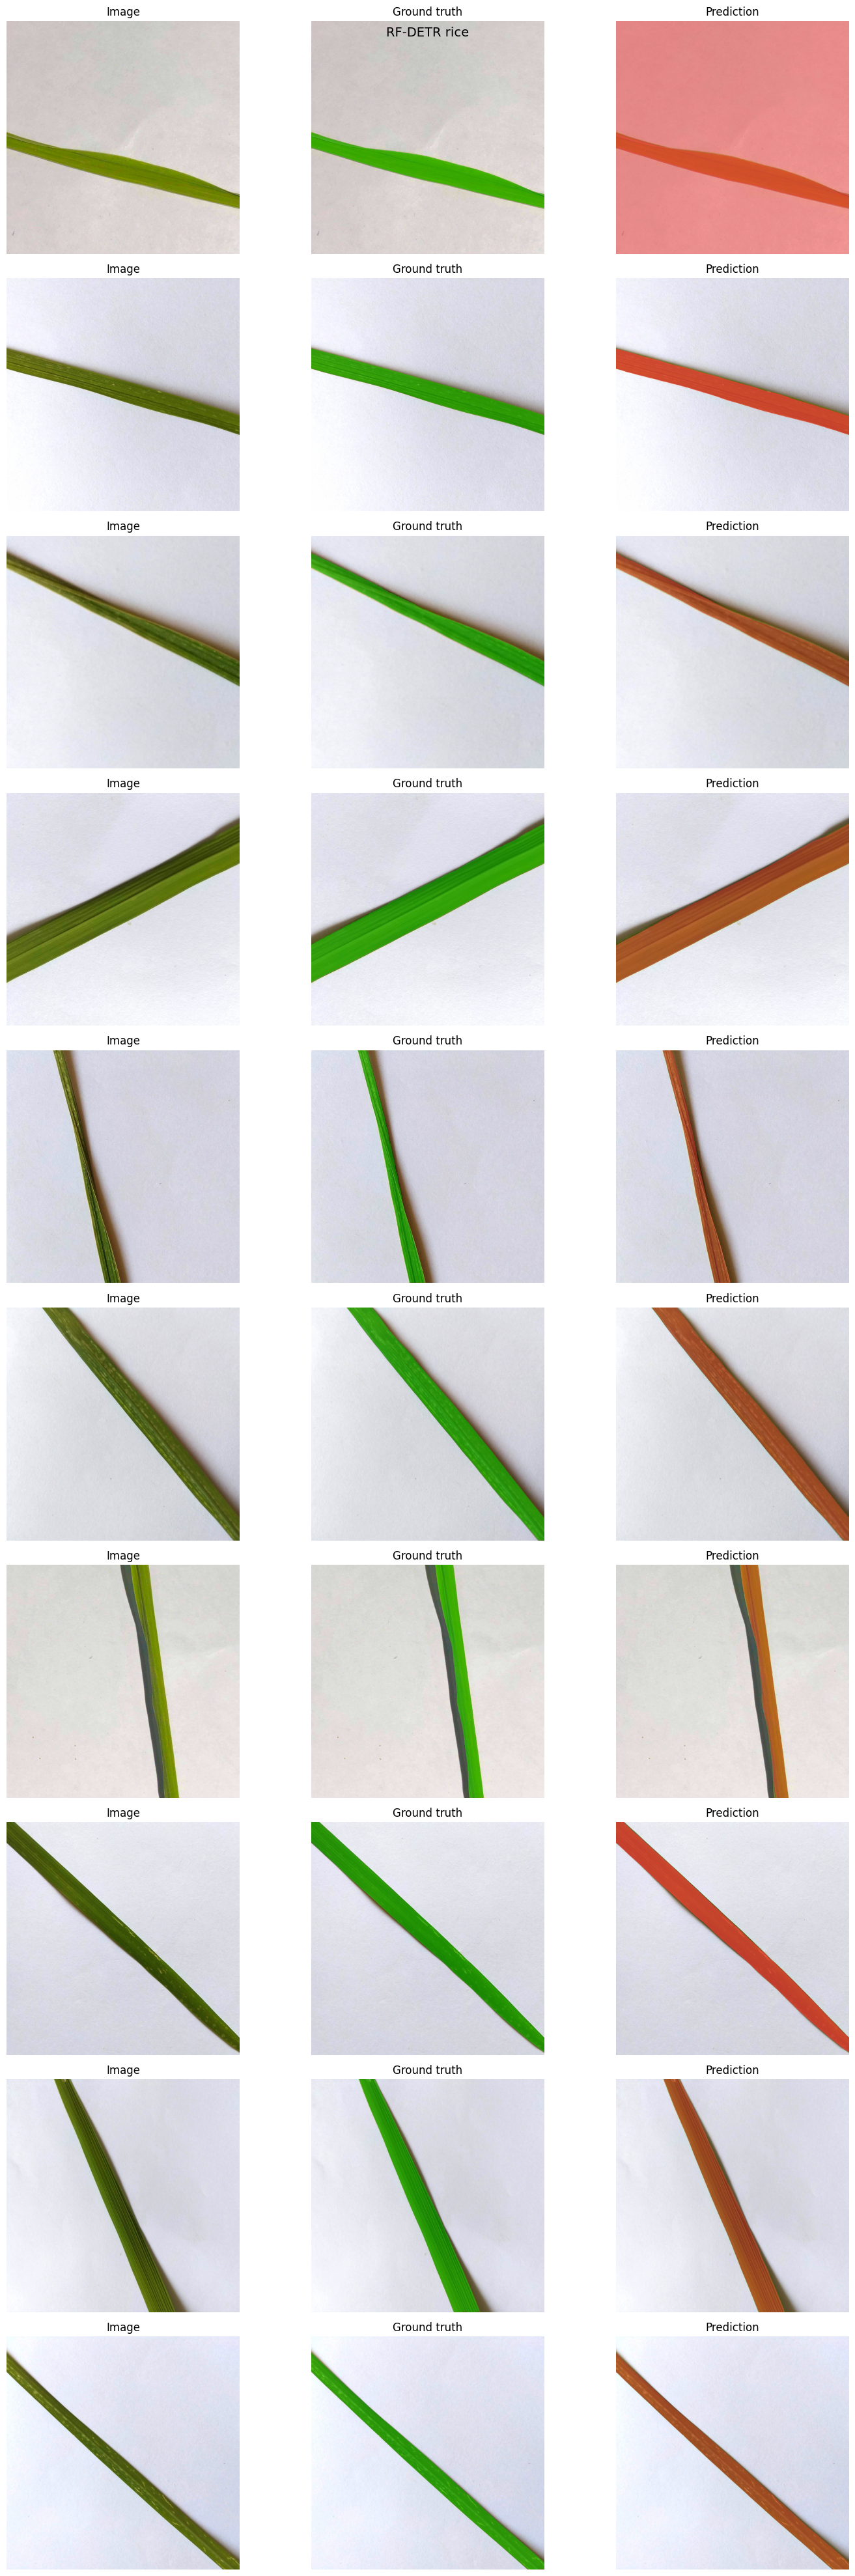

In [7]:
trained_models = {}

if not metrics_df.empty:
    for run in trained_runs:
        domain = run["domain"]
        trained_models[domain] = run
        print(f"Trained model for {domain}: {run['config']['name']}")
        print(f"Checkpoint for {domain}: {run['checkpoint']}")
else:
    print("No metrics available, so no trained model was selected for visualization/upload.")


def overlay_masks(image, masks, color, alpha=0.45):
    out = image.copy().astype(np.float32)
    color_arr = np.array(color, dtype=np.float32)
    for mask in masks:
        if mask is not None:
            mask = mask.astype(bool)
            out[mask] = out[mask] * (1 - alpha) + color_arr * alpha
    return np.clip(out, 0, 255).astype(np.uint8)


def visualize_predictions(model, dataset_dir: Path, title_prefix: str, split="test", n=10, threshold=0.35):
    split_dir = dataset_dir / split
    coco = COCO(str(split_dir / "_annotations.coco.json"))
    img_ids = sorted(coco.getImgIds())[:n]
    if not img_ids:
        print(f"No images to visualize for {title_prefix}.")
        return

    rows = []
    for img_id in img_ids:
        info = coco.loadImgs([img_id])[0]
        image_path = image_file_for_coco(split_dir, info["file_name"])
        image = np.array(Image.open(image_path).convert("RGB"))
        height, width = image.shape[:2]
        gt_anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))
        gt_masks = [coco_ann_to_mask(ann, height, width) for ann in gt_anns]

        detections = predict_one(model, image_path, threshold=threshold)
        _, _, _, pred_masks = detection_arrays(detections)
        if pred_masks is None:
            pred_masks = []
        resized_masks = []
        for mask in pred_masks:
            if mask.shape[:2] != (height, width):
                mask = cv2.resize(mask.astype(np.uint8), (width, height), interpolation=cv2.INTER_NEAREST)
            resized_masks.append(mask.astype(bool))

        rows.append(
            (
                info["file_name"],
                image,
                overlay_masks(image, gt_masks, color=(0, 220, 0)),
                overlay_masks(image, resized_masks, color=(255, 60, 60)),
            )
        )

    fig, axes = plt.subplots(len(rows), 3, figsize=(15, max(4, 4 * len(rows))))
    if len(rows) == 1:
        axes = np.expand_dims(axes, 0)
    fig.suptitle(title_prefix, fontsize=14)
    for ax_row, (name, image, gt_overlay, pred_overlay) in zip(axes, rows):
        for ax, title, img in zip(ax_row, ["Image", "Ground truth", "Prediction"], [image, gt_overlay, pred_overlay]):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis("off")
        ax_row[0].set_ylabel(name, fontsize=8)
    plt.tight_layout()
    plt.show()


for domain, run in trained_models.items():
    visualize_predictions(run["model"], run["dataset_dir"], title_prefix=f"RF-DETR {domain}", split="test", n=3 if QUICK_RUN else 10)

In [8]:
for domain, run in trained_models.items():
    run_key = f"{domain}/{run['config']['name']}"
    if run_key not in per_image_tables:
        continue
    print(f"\n===== Error analysis: {domain} =====")
    err_df = per_image_tables[run_key].copy()
    err_df["missed_or_extra"] = (
        (err_df["n_gt"] - err_df["matched"]).clip(lower=0)
        + (err_df["n_pred"] - err_df["matched"]).clip(lower=0)
    )
    err_df = err_df.sort_values(["mean_iou", "missed_or_extra"], ascending=[True, False])
    display(err_df.head(10))

print("Error analysis notes:")
print("- This notebook trains/evaluates only the rice model.")
print("- Low IoU can indicate small lesions, ambiguous symptoms, weak raw annotations, or class imbalance.")
print("- If a domain over-detects, increase threshold or improve labels for that domain.")


===== Error analysis: rice =====


,image_id,file_name,n_gt,n_pred,matched,mean_iou,mean_dice,inference_ms,missed_or_extra
340,341,test_000341_rice_img_629fbc86.jpeg,8,0,0,0.0,0.0,71.357368,8
1,2,test_000002_rice_IMG_20190419_140353.jpg,1,2,0,0.0,0.0,223.803027,3
141,142,test_000142_rice_IMG_20190419_161748.jpg,1,2,0,0.0,0.0,220.194140,3
183,184,test_000184_rice_IMG_20190419_172657.jpg,1,2,0,0.0,0.0,421.079843,3
316,317,test_000317_rice_IMG_20190419_113616.jpg,1,2,0,0.0,0.0,138.836923,3
423,424,test_000424_rice_IMG_5493.jpg,1,2,0,0.0,0.0,87.552559,3
433,434,test_000434_rice_IMG_20190419_163126.jpg,1,2,0,0.0,0.0,175.026532,3
485,486,test_000486_rice_img_86debf41_edited.jpeg,1,2,0,0.0,0.0,64.396724,3
13,14,test_000014_rice_IMG_20190419_115032.jpg,1,1,0,0.0,0.0,162.081195,2
23,24,test_000024_rice_IMG_20190419_161716.jpg,1,1,0,0.0,0.0,139.643953,2


Error analysis notes:
- This notebook trains/evaluates only the rice model.
- Low IoU can indicate small lesions, ambiguous symptoms, weak raw annotations, or class imbalance.
- If a domain over-detects, increase threshold or improve labels for that domain.


In [9]:

def prediction_file_for_run(result_name: str, split: str = "test") -> Path:
    return ARTIFACT_DIR / f"predictions_{safe_name(result_name)}_{split}.json"


def load_training_curve(run_dir: Path, selected_metrics: dict) -> pd.DataFrame:
    """Return per-epoch training logs when available; otherwise one final-metric row."""
    csv_candidates = [
        p for p in run_dir.rglob("*.csv")
        if p.name not in {"metrics.csv"} and "per_image" not in p.name.lower()
    ]

    for path in csv_candidates:
        try:
            df = pd.read_csv(path)
        except Exception:
            continue

        lower_cols = {str(col).lower() for col in df.columns}
        has_epoch_or_step = bool({"epoch", "step"} & lower_cols)
        has_metric_col = any(
            key in col
            for col in lower_cols
            for key in ["loss", "map", "iou", "dice", "acc", "precision", "recall", "f1"]
        )

        if has_epoch_or_step and has_metric_col:
            df = df.copy()
            df["source_file"] = str(path)
            return df

    event_rows = []

    try:
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

        for event_file in run_dir.rglob("events.out.tfevents*"):
            try:
                ea = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
                ea.Reload()

                for tag in ea.Tags().get("scalars", []):
                    for item in ea.Scalars(tag):
                        event_rows.append(
                            {
                                "tb_step": int(item.step),
                                "tag": str(tag),
                                "value": float(item.value),
                            }
                        )
            except Exception:
                continue

    except Exception as exc:
        print(f"TensorBoard logs could not be parsed: {exc}")

    if event_rows:
        long_df = pd.DataFrame(event_rows)

        # Nếu TensorBoard có tag tên "epoch", đổi tên để không đụng với cột epoch chính.
        long_df["tag"] = long_df["tag"].astype(str)
        long_df.loc[long_df["tag"].str.lower() == "epoch", "tag"] = "logged_epoch"

        curve_df = (
            long_df.pivot_table(
                index="tb_step",
                columns="tag",
                values="value",
                aggfunc="last",
            )
            .reset_index()
            .rename(columns={"tb_step": "epoch"})
            .sort_values("epoch")
        )

        curve_df.columns = [str(col) for col in curve_df.columns]

        # Đưa epoch về int nếu được.
        try:
            curve_df["epoch"] = curve_df["epoch"].astype(int)
        except Exception:
            pass

        return curve_df

    final_row = {
        "epoch": int(TRAIN_CONFIG.get("epochs", 0)),
        "note": "training_log_not_found_final_metrics_only",
    }

    for key, value in selected_metrics.items():
        if isinstance(value, (int, float, np.integer, np.floating)):
            final_row[key] = float(value)

    return pd.DataFrame([final_row])


def save_result_plot(result_df: pd.DataFrame, output_path: Path):
    numeric_cols = [
        col for col in result_df.columns
        if col not in {"epoch", "step"} and pd.api.types.is_numeric_dtype(result_df[col])
    ]
    metric_cols = [
        col for col in numeric_cols
        if any(key in col.lower() for key in ["loss", "map", "iou", "dice", "acc", "precision", "recall", "f1"])
    ]
    if not metric_cols:
        metric_cols = numeric_cols[:8]

    plt.figure(figsize=(12, 6))
    if result_df.shape[0] > 1 and ("epoch" in result_df.columns or "step" in result_df.columns):
        x_col = "epoch" if "epoch" in result_df.columns else "step"
        for col in metric_cols[:12]:
            plt.plot(result_df[x_col], result_df[col], marker="o", linewidth=1.8, label=col)
        plt.xlabel(x_col)
        plt.ylabel("value")
        plt.title("Learning curves")
        plt.legend(loc="best", fontsize=8)
    else:
        values = result_df[metric_cols].iloc[0] if metric_cols else pd.Series(dtype=float)
        values = values.dropna()
        values.plot(kind="bar")
        plt.ylabel("value")
        plt.title("Final evaluation metrics (per-epoch training log not found)")
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=180)
    plt.close()


def decode_prediction_mask(pred: dict, height: int, width: int) -> np.ndarray:
    seg = pred.get("segmentation")
    if seg:
        try:
            return mask_utils.decode(seg).astype(bool)
        except Exception:
            pass
    x, y, w, h = pred.get("bbox", [0, 0, 0, 0])
    mask = np.zeros((height, width), dtype=bool)
    x1, y1 = max(0, int(x)), max(0, int(y))
    x2, y2 = min(width, int(x + w)), min(height, int(y + h))
    mask[y1:y2, x1:x2] = True
    return mask


def build_confusion_outputs(dataset_dir: Path, prediction_path: Path, output_dir: Path, split: str = "test", iou_threshold: float = 0.5):
    split_dir = dataset_dir / split
    coco_gt = COCO(str(split_dir / "_annotations.coco.json"))
    cat_name = {int(cat_id): cat["name"] for cat_id, cat in coco_gt.cats.items()}
    class_labels = [cat_name[cat_id] for cat_id in sorted(cat_name)]
    matrix_labels = class_labels + ["__missed__", "__background__"]
    confusion = pd.DataFrame(0, index=matrix_labels, columns=matrix_labels, dtype=int)

    predictions = []
    if prediction_path.exists():
        with open(prediction_path, "r", encoding="utf-8") as f:
            predictions = json.load(f)
    preds_by_image = {}
    for pred in predictions:
        preds_by_image.setdefault(int(pred["image_id"]), []).append(pred)

    for img_id in sorted(coco_gt.getImgIds()):
        img_info = coco_gt.loadImgs([img_id])[0]
        height, width = int(img_info["height"]), int(img_info["width"])
        gt_anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=[img_id]))
        pred_items = preds_by_image.get(int(img_id), [])

        pred_masks = [decode_prediction_mask(pred, height, width) for pred in pred_items]
        pred_labels = [cat_name.get(int(pred.get("category_id")), str(pred.get("category_id"))) for pred in pred_items]
        used_preds = set()

        for ann in gt_anns:
            gt_label = cat_name[int(ann["category_id"])]
            gt_mask = coco_ann_to_mask(ann, height, width)
            best_iou, best_idx = 0.0, None
            for pred_idx, pred_mask in enumerate(pred_masks):
                if pred_idx in used_preds:
                    continue
                inter = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                iou = float(inter / union) if union else 0.0
                if iou > best_iou:
                    best_iou, best_idx = iou, pred_idx
            if best_idx is not None and best_iou >= iou_threshold:
                confusion.loc[gt_label, pred_labels[best_idx]] += 1
                used_preds.add(best_idx)
            else:
                confusion.loc[gt_label, "__missed__"] += 1

        for pred_idx, pred_label in enumerate(pred_labels):
            if pred_idx not in used_preds:
                confusion.loc["__background__", pred_label] += 1

    class_metric_rows = []
    for label in class_labels:
        tp = int(confusion.loc[label, label])
        fp = int(confusion.loc[[idx for idx in matrix_labels if idx != label], label].sum())
        fn = int(confusion.loc[label, [col for col in matrix_labels if col != label]].sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        class_metric_rows.append(
            {"class": label, "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}
        )
    class_metrics = pd.DataFrame(class_metric_rows)

    output_dir.mkdir(parents=True, exist_ok=True)
    confusion.to_csv(output_dir / "confusion_matrix.csv")
    class_metrics.to_csv(output_dir / "test_classification_metrics.csv", index=False)

    plt.figure(figsize=(max(8, len(matrix_labels) * 1.2), max(6, len(matrix_labels) * 1.0)))
    try:
        import seaborn as sns

        sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False)
    except Exception:
        plt.imshow(confusion.values, cmap="Blues")
        plt.xticks(range(len(matrix_labels)), matrix_labels, rotation=45, ha="right")
        plt.yticks(range(len(matrix_labels)), matrix_labels)
        for row_idx in range(confusion.shape[0]):
            for col_idx in range(confusion.shape[1]):
                plt.text(col_idx, row_idx, str(confusion.iat[row_idx, col_idx]), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Ground truth")
    plt.title(f"Confusion matrix ({split}, IoU >= {iou_threshold})")
    plt.tight_layout()
    plt.savefig(output_dir / "confusion_matrix.png", dpi=180)
    plt.close()
    return confusion, class_metrics


def export_standard_outputs(domain: str, run: dict, selected_metrics: dict, best_dir: Path):
    domain_dir = ARTIFACT_DIR / domain
    run_dir = Path(run["run_dir"])
    run_name = run["config"]["name"]

    result_df = load_training_curve(run_dir, selected_metrics)
    for out_dir in [domain_dir, best_dir]:
        out_dir.mkdir(parents=True, exist_ok=True)
        result_df.to_csv(out_dir / "result.csv", index=False)
        save_result_plot(result_df, out_dir / "result.png")

    pred_path = prediction_file_for_run(f"{domain}/{run_name}", split="test")
    confusion, class_metrics = build_confusion_outputs(run["dataset_dir"], pred_path, domain_dir, split="test", iou_threshold=0.5)
    confusion.to_csv(best_dir / "confusion_matrix.csv")
    class_metrics.to_csv(best_dir / "test_classification_metrics.csv", index=False)
    shutil.copy2(domain_dir / "confusion_matrix.png", best_dir / "confusion_matrix.png")

    print(f"Standard outputs saved for {domain}:")
    print(f"- {domain_dir / 'best.pt'}")
    print(f"- {domain_dir / 'result.csv'}")
    print(f"- {domain_dir / 'result.png'}")
    print(f"- {domain_dir / 'confusion_matrix.png'}")


def get_kaggle_secret(name):
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(name)
    except Exception:
        return None


def repo_id_for_domain(domain: str) -> str | None:
    explicit_repo = (HF_REPO_ID or os.getenv("HF_REPO_ID", "") or get_kaggle_secret("HF_REPO_ID") or "").strip()
    hf_org = (os.getenv("HF_ORG", "") or get_kaggle_secret("HF_ORG") or "").strip()
    hf_username = (os.getenv("HF_USERNAME", "") or get_kaggle_secret("HF_USERNAME") or "").strip()

    if explicit_repo:
        if "/" not in explicit_repo:
            owner = hf_org or hf_username
            if not owner:
                return None
            explicit_repo = f"{owner}/{explicit_repo}"
        if HF_UPLOAD_SINGLE_REPO:
            return explicit_repo
        if explicit_repo.endswith(f"-{domain}"):
            return explicit_repo
        return f"{explicit_repo}-{domain}"

    owner = hf_org or hf_username
    if not owner:
        return None
    if HF_UPLOAD_SINGLE_REPO:
        return f"{owner}/coffee-rice-leaf-disease-rf-detr"
    return f"{owner}/rf-detr-{domain}-plant-disease"


def path_in_repo_for_domain(domain: str) -> str | None:
    return domain if HF_UPLOAD_SINGLE_REPO else None


def write_json(path: Path, payload: dict):
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")


prepared_uploads = {}

for domain, run in trained_models.items():
    domain_dir = ARTIFACT_DIR / domain
    best_dir = domain_dir / "best_model"
    best_dir.mkdir(parents=True, exist_ok=True)
    domain_metrics = metrics_df[metrics_df["domain"] == domain].copy()
    selected_metrics_df = domain_metrics[domain_metrics["run"] == run["config"]["name"]]
    selected_metrics = selected_metrics_df.iloc[0].to_dict() if not selected_metrics_df.empty else {}

    checkpoint_name = None
    if run["checkpoint"] and Path(run["checkpoint"]).exists():
        checkpoint_path = Path(run["checkpoint"])
        checkpoint_name = "best.pt"
        shutil.copy2(checkpoint_path, best_dir / checkpoint_name)
        shutil.copy2(checkpoint_path, domain_dir / checkpoint_name)
    else:
        print(f"Warning: no checkpoint file found for {domain}. HuggingFace upload will contain metadata only.")

    if (run["dataset_dir"] / "class_names.json").exists():
        shutil.copy2(run["dataset_dir"] / "class_names.json", best_dir / "class_names.json")
    if not domain_metrics.empty:
        domain_metrics.to_csv(best_dir / "metrics.csv", index=False)
    export_standard_outputs(domain, run, selected_metrics, best_dir)

    model_config = {
        "model_family": "RF-DETR Segmentation",
        "domain": domain,
        "model_size": run["config"].get("model_size"),
        "checkpoint_file": checkpoint_name,
        "class_names_file": "class_names.json",
        "metrics_file": "metrics.csv",
        "source_raw_data": str(raw_root) if "raw_root" in globals() else None,
        "uses_processed_extra": bool(USE_PROCESSED_EXTRA),
        "processed_dir": str(processed_root) if "processed_root" in globals() and processed_root else None,
        "best_run": run["config"]["name"],
        "train_config": run["config"],
        "selected_metrics": selected_metrics,
        "load_hint": "Use rfdetr RFDETRSeg* with pretrain_weights pointing to checkpoint_file.",
    }
    write_json(best_dir / "config.json", model_config)

    model_card = best_dir / "README.md"
    with open(model_card, "w", encoding="utf-8") as f:
        f.write(f"# RF-DETR Segmentation - {domain.title()} Plant Disease\n\n")
        f.write(f"Fine-tuned RF-DETR segmentation model for the `{domain}` subset of the rice/coffee leaf disease dataset.\n\n")
        f.write("## Files\n\n")
        f.write("- `config.json`: model metadata and train config\n")
        f.write("- `class_names.json`: COCO category id to label mapping\n")
        f.write("- `metrics.csv`: evaluation metrics for this training run\n")
        if checkpoint_name:
            f.write(f"- `{checkpoint_name}`: best RF-DETR checkpoint\n")
        f.write("\n## Train Config\n\n```json\n")
        f.write(json.dumps(run["config"], indent=2))
        f.write("\n```\n\n## Selected Metrics\n\n")
        f.write(pd.DataFrame([selected_metrics]).to_markdown(index=False))
        f.write("\n\n## Data Notes\n\n")
        f.write("- Raw COCO annotations are used as the primary training source.\n")
        f.write("- Processed data is included as extra data when `USE_PROCESSED_EXTRA=1`; those records use pseudo full-image annotations because processed/ has no lesion COCO masks.\n")
        f.write("- Invalid/background labels such as `uit` are filtered before training.\n")

    prepared_uploads[domain] = {
        "folder": best_dir,
        "repo_id": repo_id_for_domain(domain),
        "path_in_repo": path_in_repo_for_domain(domain),
        "checkpoint": checkpoint_name,
    }
    hf_target_path = prepared_uploads[domain]["path_in_repo"]
    hf_target = prepared_uploads[domain]["repo_id"] or "<missing owner/repo>"
    if hf_target_path:
        hf_target = f"{hf_target}/{hf_target_path}"
    print(f"Best artifacts for {domain} prepared at: {best_dir}")
    print(f"Suggested HuggingFace target for {domain}: {hf_target}")

    if EXPORT_ONNX:
        try:
            run["model"].export(output_dir=str(domain_dir / "onnx"), batch_size=1, dynamic_batch=True)
        except TypeError:
            run["model"].export()
        print(f"ONNX export requested for {domain}.")


hf_token = os.getenv("HF_TOKEN") or get_kaggle_secret("HF_TOKEN")

if RUN_HF_PUSH:
    if not hf_token:
        print("RUN_HF_PUSH=1 but HF_TOKEN is missing. Add HF_TOKEN as a Kaggle Secret or environment variable.")
    else:
        from huggingface_hub import create_repo, upload_folder

        for domain, upload_info in prepared_uploads.items():
            repo_id = upload_info["repo_id"]
            upload_dir = upload_info["folder"]
            if not repo_id:
                print(f"Skipping {domain}: missing HF_REPO_ID or HF_ORG/HF_USERNAME.")
                continue
            if not upload_dir.exists():
                print(f"Skipping {domain}: upload folder does not exist: {upload_dir}")
                continue
            create_repo(repo_id, token=hf_token, private=False, exist_ok=True)
            path_in_repo = upload_info.get("path_in_repo")
            upload_folder(
                repo_id=repo_id,
                folder_path=str(upload_dir),
                path_in_repo=path_in_repo,
                token=hf_token,
                commit_message=f"Upload RF-DETR {domain} checkpoint, metrics, and metadata",
            )
            target_url = f"https://huggingface.co/{repo_id}"
            if path_in_repo:
                target_url = f"{target_url}/tree/main/{path_in_repo}"
            print(f"Uploaded {domain} model to {target_url}")
else:
    print("HF push is disabled.")
    print("To upload from Kaggle, set RUN_HF_PUSH=1 and add HF_TOKEN.")
    print(f"Default HF_REPO_ID is {HF_REPO_ID}.")
    print("With HF_UPLOAD_SINGLE_REPO=1, files are uploaded under coffee/ or rice/ inside that repo.")
    print("Set HF_UPLOAD_SINGLE_REPO=0 only if you want separate repos per domain.")

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Standard outputs saved for rice:
- /kaggle/working/rf_detr_artifacts/rice/best.pt
- /kaggle/working/rf_detr_artifacts/rice/result.csv
- /kaggle/working/rf_detr_artifacts/rice/result.png
- /kaggle/working/rf_detr_artifacts/rice/confusion_matrix.png
Best artifacts for rice prepared at: /kaggle/working/rf_detr_artifacts/rice/best_model
Suggested HuggingFace target for rice: fuxi611/coffee-rice-leaf-disease-rf-detr/rice
HF push is disabled.
To upload from Kaggle, set RUN_HF_PUSH=1 and add HF_TOKEN.
Default HF_REPO_ID is fuxi611/coffee-rice-leaf-disease-rf-detr.
With HF_UPLOAD_SINGLE_REPO=1, files are uploaded under coffee/ or rice/ inside that repo.
Set HF_UPLOAD_SINGLE_REPO=0 only if you want separate repos per domain.
